In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm 
import timm 
import json
import time

# 1. Load Data
df = pd.read_csv('data/train.csv')
df = df.sort_values('Image').reset_index(drop=True) 

# 2. Split Data
test_size = 0.1
val_size = 0.1
train_val, test = train_test_split(df, test_size=test_size, random_state=42, shuffle=True)
val_relative_size = val_size / (1 - test_size)
train, val = train_test_split(train_val, test_size=val_relative_size, random_state=42, shuffle=True)

# 3. FILTER OUT new_whale for the baseline training
train = train[train['Id'] != 'new_whale'].reset_index(drop=True)
val = val[val['Id'] != 'new_whale'].reset_index(drop=True)

# 4. Create class mappings ONLY for known whales
train_labels = sorted(list(set(train['Id'].unique())))
id_to_idx = {name: i for i, name in enumerate(train_labels)}
idx_to_id = {i: name for name, i in id_to_idx.items()} # Useful for inference later
num_classes = len(id_to_idx)

print(f"Training on {num_classes} unique whales.")

Training on 3787 unique whales.


In [2]:
IMAGE_SIZE = (256, 256) # Standard for ConvNeXt. If you have extra VRAM, try (256, 256)

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(degrees=10), 
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class WhaleDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        # Update path to match your local setup
        img_name = f"data/train/{self.df.iloc[idx]['Image']}"
        image = Image.open(img_name).convert('RGB')
        row_id = self.df.iloc[idx]['Id']
        label = id_to_idx.get(row_id, -1)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Create DataLoaders (adjust batch_size based on your laptop's memory. 16 or 32 is safe)
train_dataset = WhaleDataset(train, transform=train_transform)
val_dataset = WhaleDataset(val, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Load ConvNeXt. timm automatically replaces the final classification layer for our num_classes
model = timm.create_model('convnext_tiny', pretrained=True, num_classes=num_classes)
model = model.to(device)

# 1. Calculate weights: Rare classes get HIGH weights, Common classes get LOW weights
class_counts = train['Id'].value_counts().sort_index().values
weights = 1.0 / class_counts

# Normalize weights so they don't explode (optional but good practice)
weights = weights / weights.sum() * len(class_counts)

# Convert to tensor
class_weights_tensor = torch.FloatTensor(weights).to(device)

# 2. Pass these weights to the Loss Function
# Note: We still use ignore_index=-1
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, ignore_index=-1, label_smoothing=0.1)

# AdamW is the standard and best optimizer for ConvNeXt architectures
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Optional but highly recommended: Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

Using device: cpu


In [ ]:
epochs = 10
best_val_acc = 0.0

# Added 'epoch_times' to store how long each epoch takes
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [],  'val_acc':[],
    'epoch_times':[] 
}

print("Starting training...")
total_start_time = time.time()

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    epoch_start_time = time.time()
    
    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    
    train_pbar = tqdm(train_loader, desc="Training", leave=False)
    
    for images, labels in train_pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        batch_size = images.size(0)
        train_loss += loss.item() * batch_size
        _, preds = torch.max(outputs, 1)
        train_correct += torch.sum(preds == labels.data).item()
        train_total += batch_size
        
        current_loss = train_loss / train_total
        current_acc = train_correct / train_total
        
        # Multiply by 100 to display as a percentage
        train_pbar.set_postfix({
            'loss': f'{current_loss:.4f}', 
            'acc': f'{current_acc * 100:.2f}%'
        })
        
    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    
    val_pbar = tqdm(val_loader, desc="Validating", leave=False)
    
    # We pick a threshold. If confidence is lower than this, we predict 'new_whale' (-1)
    THRESHOLD = 0.5 
    
    with torch.no_grad():
        for images, labels in val_pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels) # This works now because of ignore_index=-1
            
            # --- CUSTOM ACCURACY LOGIC ---
            # 1. Get probabilities (0.0 to 1.0) instead of raw logits
            probs = torch.nn.functional.softmax(outputs, dim=1)
            
            # 2. Get the highest probability and the class index
            max_probs, preds = torch.max(probs, dim=1)
            
            # 3. Apply Threshold: 
            # If confidence < threshold, change prediction to -1 (representing new_whale)
            preds[max_probs < THRESHOLD] = -1
            
            # 4. Calculate stats
            # Note: If label is -1 (unseen whale), loss.item() might be 0.0 due to ignore_index.
            # We only add loss if it's not 0, or just accept it (it won't affect training).
            if loss.item() != 0.0:
                 val_loss += loss.item() * images.size(0)
            
            val_correct += torch.sum(preds == labels.data).item()
            val_total += labels.size(0)
            
            current_acc = val_correct / val_total
            # For display, we might see 0.0 loss if the batch is full of new_whales, that's fine.
            display_loss = val_loss / val_total if val_total > 0 else 0
            
            val_pbar.set_postfix({
                'loss': f'{display_loss:.4f}', 
                'acc': f'{current_acc * 100:.2f}%'
            })
            
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    
    # Calculate how long the epoch took
    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    
    scheduler.step(epoch_val_loss)
    
    # Store metrics and time
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    history['epoch_times'].append(epoch_duration)
    
    # Print formatted summary
    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc * 100:.2f}%")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc * 100:.2f}%")
    print(f"Time taken: {epoch_duration / 60:.2f} minutes")
    
    # --- SAVE BEST MODEL ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), 'best_baseline.pth')
        print("--> Saved new best model!")

# --- WRAP UP AND SAVE HISTORY ---
total_time = time.time() - total_start_time
history['total_time_seconds'] = total_time
print(f"\nTraining complete in {total_time / 60:.2f} minutes.")

# Save the history dictionary to a JSON file
with open('training_history.json', 'w') as f:
    json.dump(history, f)
print("Training history saved to 'training_history.json'.")

Starting training...

Epoch 1/10


Training:   0%|          | 0/113 [00:00<?, ?it/s]

Validating:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 8.6370 | Train Acc: 0.01%
Val Loss:   8.6222 | Val Acc:   29.69%
Time taken: 16.80 minutes
--> Saved new best model!

Epoch 2/10


Training:   0%|          | 0/113 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 8.6077 | Train Acc: 0.00%
Val Loss:   8.5433 | Val Acc:   29.69%
Time taken: 16.59 minutes

Epoch 10/10


Training:   0%|          | 0/113 [00:00<?, ?it/s]

Validating:   0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 8.6061 | Train Acc: 0.00%
Val Loss:   8.5441 | Val Acc:   29.69%
Time taken: 16.65 minutes

Training complete in 169.62 minutes.
Training history saved to 'training_history.json'.


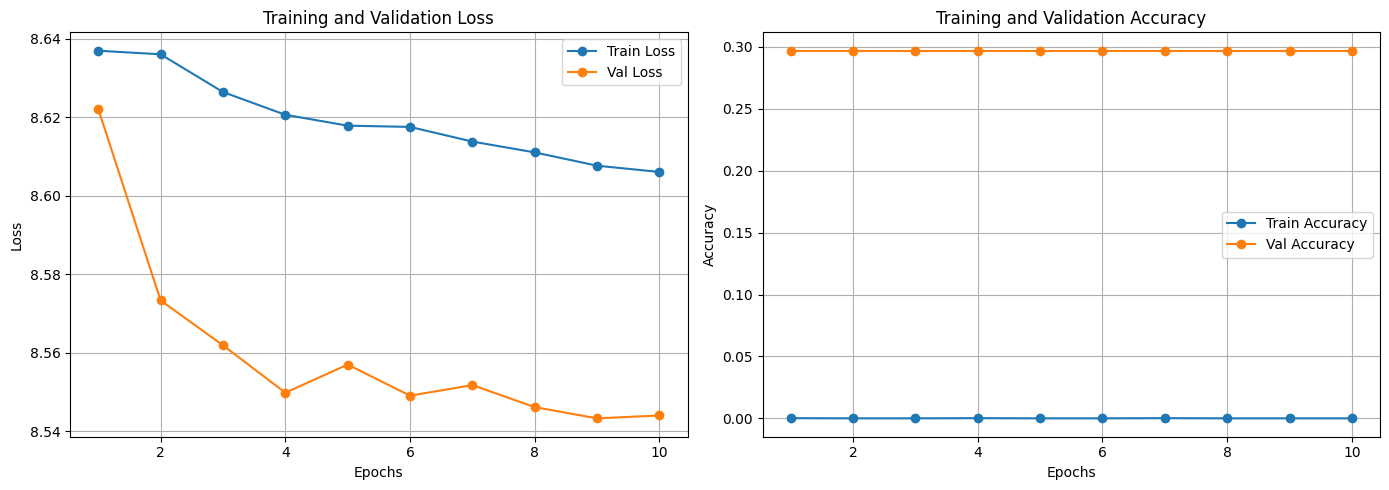

In [5]:
def plot_training_history(history):
    epochs_range = range(1, len(history['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss
    ax1.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(epochs_range, history['val_loss'], label='Val Loss', marker='o')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Plot Accuracy
    ax2.plot(epochs_range, history['train_acc'], label='Train Accuracy', marker='o')
    ax2.plot(epochs_range, history['val_acc'], label='Val Accuracy', marker='o')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Load the saved history
with open('training_history.json', 'r') as f:
    loaded_history = json.load(f)
    plot_training_history(loaded_history)

In [7]:
# Load the best weights back into the model
model.load_state_dict(torch.load('best_baseline.pth'))
model.eval()

# Example inference function for a single image to demonstrate thresholding
def predict_whale(image_tensor, model, threshold=0.4):
    image_tensor = image_tensor.unsqueeze(0).to(device) # Add batch dimension
    
    with torch.no_grad():
        logits = model(image_tensor)
        probabilities = torch.nn.functional.softmax(logits, dim=1)[0]
        
    # Get top 5 predictions from the known whales
    top5_probs, top5_indices = torch.topk(probabilities, 5)
    
    top5_probs = top5_probs.cpu().numpy()
    top5_indices = top5_indices.cpu().numpy()
    
    predictions = [idx_to_id[idx] for idx in top5_indices]
    
    # Threshold Logic
    if top5_probs[0] < threshold:
        # If the model is not confident, 'new_whale' becomes the #1 prediction
        predictions = ['new_whale'] + predictions[:4]
    else:
        # Otherwise, assume it's a known whale, but put 'new_whale' as a fallback backup at #2 or #5
        # Depending on competition strategy, appending it at the end is safe
        predictions = predictions[:4] + ['new_whale'] 
        
    return predictions

# Usage:
# preds = predict_whale(sample_image_tensor, model, threshold=0.35)
# print("Top 5 Predictions:", preds)